In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
import nltk
from nltk.tokenize import sent_tokenize , word_tokenize
from collections import Counter
import spacy
import networkx as nx
from gensim import corpora , models

In [71]:
files = [
    "001ssb.txt",
    "002ssb.txt",
    "003ssb.txt",
    "004ssb.txt",
    "005ssb.txt",
]

text = ""

for file in files:
    with open(file, "r", encoding="latin-1") as f:
        text += f.read() + "\n"

In [72]:
len(text)

9778338

In [13]:
text[:1000]

'A Game Of Thrones \nBook One of A Song of Ice and Fire \nBy George R. R. Martin \nPROLOGUE \n"We should start back," Gared urged as the woods began to grow dark around them. "The wildlings are \ndead." \n"Do the dead frighten you?" Ser Waymar Royce asked with just the hint of a smile. \nGared did not rise to the bait. He was an old man, past fifty, and he had seen the lordlings come and go. \n"Dead is dead," he said. "We have no business with the dead." \n"Are they dead?" Royce asked softly. "What proof have we?" \n"Will saw them," Gared said. "If he says they are dead, that\'s proof enough for me." \nWill had known they would drag him into the quarrel sooner or later. He wished it had been later rather \nthan sooner. "My mother told me that dead men sing no songs," he put in. \n"My wet nurse said the same thing, Will," Royce replied. "Never believe anything you hear at a woman\'s \ntit. There are things to be learned even from the dead." His voice echoed, too loud in the twilit fores

# **Text Preprocessing**

In [ ]:
text = text.lower()
text = re.sub(r'\n+' , '' , text)
text = text.replace('"' , '')

In [18]:
text[:1001]

"a game of thrones book one of a song of ice and fire by george r. r. martin prologue we should start back, gared urged as the woods began to grow dark around them. the wildlings are dead. do the dead frighten you? ser waymar royce asked with just the hint of a smile. gared did not rise to the bait. he was an old man, past fifty, and he had seen the lordlings come and go. dead is dead, he said. we have no business with the dead. are they dead? royce asked softly. what proof have we? will saw them, gared said. if he says they are dead, that's proof enough for me. will had known they would drag him into the quarrel sooner or later. he wished it had been later rather than sooner. my mother told me that dead men sing no songs, he put in. my wet nurse said the same thing, will, royce replied. never believe anything you hear at a woman's tit. there are things to be learned even from the dead. his voice echoed, too loud in the twilit forest. page 1we have a long ride before us, gared pointed 

# **Sentence Tokenizer**

In [20]:
sentence = sent_tokenize(text)
sentence[:10]

['a game of thrones book one of a song of ice and fire by george r. r. martin prologue we should start back, gared urged as the woods began to grow dark around them.',
 'the wildlings are dead.',
 'do the dead frighten you?',
 'ser waymar royce asked with just the hint of a smile.',
 'gared did not rise to the bait.',
 'he was an old man, past fifty, and he had seen the lordlings come and go.',
 'dead is dead, he said.',
 'we have no business with the dead.',
 'are they dead?',
 'royce asked softly.']

In [21]:
text = re.sub(r'[^a-zA-Z\s]' , '' , text)

# **Word Tokenizer**

In [25]:
tokens = word_tokenize(text)

In [26]:
tokens[:30]

['a',
 'game',
 'of',
 'thrones',
 'book',
 'one',
 'of',
 'a',
 'song',
 'of',
 'ice',
 'and',
 'fire',
 'by',
 'george',
 'r',
 'r',
 'martin',
 'prologue',
 'we',
 'should',
 'start',
 'back',
 'gared',
 'urged',
 'as',
 'the',
 'woods',
 'began',
 'to']

In [47]:
freq = Counter(tokens)

print(freq.most_common(50))

[('the', 104174), ('and', 52279), ('a', 40555), ('to', 40039), ('of', 37652), ('he', 27813), ('his', 26657), ('was', 22081), ('you', 19329), ('her', 19214), ('i', 19003), ('in', 18111), ('had', 17022), ('it', 16392), ('that', 15888), ('as', 15151), ('she', 14846), ('with', 13289), ('him', 12493), ('not', 12271), ('but', 11317), ('for', 10940), ('is', 9212), ('they', 9000), ('on', 8976), ('at', 8855), ('said', 8745), ('my', 8595), ('have', 8594), ('be', 8061), ('them', 7858), ('no', 7660), ('lord', 7603), ('from', 7381), ('were', 7246), ('would', 7042), ('me', 6973), ('your', 6651), ('all', 6383), ('when', 6325), ('one', 6254), ('will', 6238), ('ser', 6016), ('if', 6016), ('so', 5782), ('their', 5418), ('could', 5090), ('are', 4972), ('this', 4462), ('we', 4439)]


# **Named Entity Recognization**

In [48]:
len(text)

9215697

In [53]:
nlp = spacy.load("en_core_web_sm") 

doc = nlp(text[:100000])

character = []

for ent in doc.ents:
    if ent.label_ == "PERSON":
        character.append(ent.text)

print(set(character))

{'robert embraced catelyn', 'jaime', 'jory desmond', 'menagerie', 'gaunt', 'robert himself', 'waymar', 'catelyn catelyn', 'robert followed', 'dothraki', 'lyanna', 'wolf', 'george r r martin prologue', 'robert grasped', 'jon arryn', 'neds king', 'robert complained', 'maester luwin', 'nan', 'prince joffrey', 'knelt', 'bran catelyn', 'drogo', 'robert have', 'robert swore', 'jon robert', 'catelyn', 'robert nodded', 'khal moro', 'stark', 'shaggy grey', 'joffrey baratheon', 'catelyn reminded', 'jorah', 'robert arryn', 'catelyn knew', 'bush', 'khal drogos', 'muster jon', 'harwin', 'robert of', 'ben stark', 'robert muttered', 'benjen stark', 'jon snow', 'robert looked', 'stark jon', 'robert', 'robert baratheon', 'danys head', 'maester aemon', 'ben'}


In [77]:
import itertools

def build_character_network(text, nlp):

    doc = nlp(text)

    G = nx.Graph()

    for sent in doc.sents:

        characters = [
            ent.text
            for ent in sent.ents
            if ent.label_ == "PERSON"
        ]

        for pair in itertools.combinations(set(characters), 2):

            if G.has_edge(*pair):
                G[pair[0]][pair[1]]["weight"] += 1
            else:
                G.add_edge(pair[0], pair[1], weight=1)

    return G

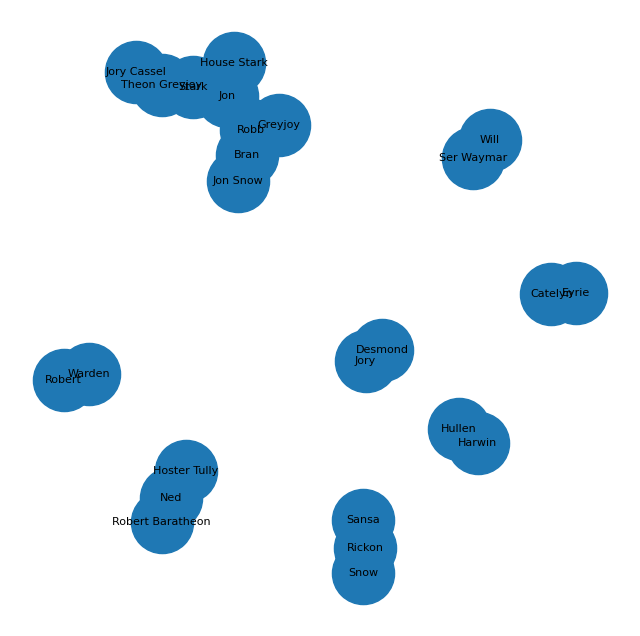

In [78]:
G = build_character_network(text[:50000], nlp)

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(
    G,
    with_labels=True,
    node_size=2000,
    font_size=8
)

# **LDA (Latent Dirichlet Allocation)**

In [65]:
dictionary = corpora.Dictionary([tokens])
corpus = [dictionary.doc2bow(tokens)]

lda = models.LdaModel(corpus=corpus , num_topics=5 , id2word=dictionary)

lda.print_topics()

[(0,
  '0.068*"the" + 0.023*"to" + 0.021*"a" + 0.021*"and" + 0.016*"of" + 0.014*"his" + 0.014*"you" + 0.013*"was" + 0.013*"he" + 0.011*"it"'),
 (1,
  '0.056*"the" + 0.031*"and" + 0.024*"of" + 0.024*"a" + 0.022*"to" + 0.017*"his" + 0.015*"he" + 0.012*"i" + 0.012*"her" + 0.011*"was"'),
 (2,
  '0.055*"the" + 0.032*"and" + 0.024*"a" + 0.022*"of" + 0.020*"he" + 0.019*"to" + 0.011*"his" + 0.011*"you" + 0.010*"was" + 0.009*"her"'),
 (3,
  '0.053*"the" + 0.031*"and" + 0.023*"to" + 0.021*"a" + 0.020*"of" + 0.016*"he" + 0.015*"was" + 0.011*"his" + 0.011*"she" + 0.010*"in"'),
 (4,
  '0.051*"the" + 0.030*"and" + 0.021*"to" + 0.019*"a" + 0.017*"was" + 0.016*"of" + 0.016*"his" + 0.013*"he" + 0.010*"in" + 0.010*"her"')]

In [67]:
from transformers import GPT2Tokenizer , GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

In [ ]:
prompt = "The night was cold and the wall stood silent"

inputs = tokenizer.encode(prompt, return_tensors="pt")

output = model.generate(
    inputs,
    max_length=100,
    num_return_sequences=1,
    temperature=0.8,
    do_sample=True
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The night was cold and the wall stood silent. The sunlight filtered out into a gray sky, the air like the moon. I turned my head to look away before I saw the man standing against the wall in front of me. He was a tall, thin human with a long white beard. He wore a pair of dark glasses, and some sort of eye patch. He looked at me for a moment, then turned to face me. "What's wrong?" I asked. "What's wrong
